#### Projeto - EDA - Renaest/Detran 2025 até setebro
 Nota: Os dados analisados apresentam 154 óbitos registrados sob o ano de referência de 2025 na base unificada do RENAEST. Estatísticas locais consolidadas pelo DETRAN Alagoas apontam 447 óbitos no período anual de 2025, indicando uma janela de defasagem de sincronização entre o relatório final e o dataset público

### Importação, filtração e tratamento

In [1]:
# Importando bibliotecas
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Importando dataset 
df_cru = pd.read_csv("renaest.csv")

In [3]:
# Filtrando colunas para explorar

colunas = ['Ano', 'ID', 'Fonte', 'Coleta', 'Data', 'Mês', 'Dia da Semana', 
           'Hora', 'Fase do Dia', 'Município', 'Bairro', 'Via', 'Rodovia', 
           'Causas Principais', 'Óbito']

df_filtrado = df_cru[colunas]
df_filtrado = df_filtrado[df_filtrado['Ano'] == 2025]

df_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1246 entries, 9676 to 10921
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Ano                1246 non-null   int64 
 1   ID                 1246 non-null   object
 2   Fonte              1246 non-null   object
 3   Coleta             1246 non-null   object
 4   Data               1246 non-null   object
 5   Mês                1246 non-null   object
 6   Dia da Semana      1246 non-null   object
 7   Hora               1246 non-null   object
 8   Fase do Dia        1244 non-null   object
 9   Município          1246 non-null   object
 10  Bairro             1105 non-null   object
 11  Via                956 non-null    object
 12  Rodovia            1246 non-null   object
 13  Causas Principais  1246 non-null   object
 14  Óbito              140 non-null    object
dtypes: int64(1), object(14)
memory usage: 155.8+ KB


In [4]:
# Tratamento de tipos e nulos (Preenchendo 'Fase do dia')

#Transformando Data, Hora e Óbito em formatos adequados
df_filtrado['Data'] = pd.to_datetime(df_filtrado['Data'], dayfirst=True,errors='coerce') 
hora_limpa = df_filtrado['Hora'].astype(str).str.replace(';', ':').str.replace('.', ':', regex=False)
df_filtrado['Hora'] = pd.to_timedelta(hora_limpa, errors='coerce')
df_filtrado['Óbito'] = pd.to_numeric(df_filtrado['Óbito'], errors='coerce')

#Preenchendo nulos de "Fase do dia" com condições e uso de .loc
mask_madrugada = df_filtrado['Fase do Dia'].isnull() & (df_filtrado['Hora'] >= '00:00:00') & (df_filtrado['Hora'] <= '05:59:59')
mask_manha = df_filtrado['Fase do Dia'].isnull() & (df_filtrado['Hora'] >= '06:00:00') & (df_filtrado['Hora'] <= '12:59:59')
mask_tarde = df_filtrado['Fase do Dia'].isnull() & (df_filtrado['Hora'] >= '13:00:00') & (df_filtrado['Hora'] <= '18:59:59')
mask_noite = df_filtrado['Fase do Dia'].isnull() & (df_filtrado['Hora'] >= '19:00:00') & (df_filtrado['Hora'] <= '23:59:59')

df_filtrado.loc[mask_madrugada, 'Fase do Dia'] = 'Madrugada'
df_filtrado.loc[mask_manha, 'Fase do Dia'] = 'Manhã'
df_filtrado.loc[mask_tarde, 'Fase do Dia'] = 'Tarde'
df_filtrado.loc[mask_noite, 'Fase do Dia'] = 'Noite'

#Tratando correções de digitação
df_filtrado['Causas Principais'] = df_filtrado['Causas Principais'].str.replace('Sem informações', 'Sem informação')
df_filtrado['Fonte'] = df_filtrado['Fonte'].str.replace('3°BPM', '3º BPM').str.replace('3 BPM', '3º BPM')

#Limpando nulos em data
df_filtrado = df_filtrado.dropna(subset=['Data'])

#Eliminando 1 linha relacionada a fase do dia totalmente sem informação
df_filtrado = df_filtrado[df_filtrado['Fase do Dia'] != 'Sem informação']


### Insights iniciais

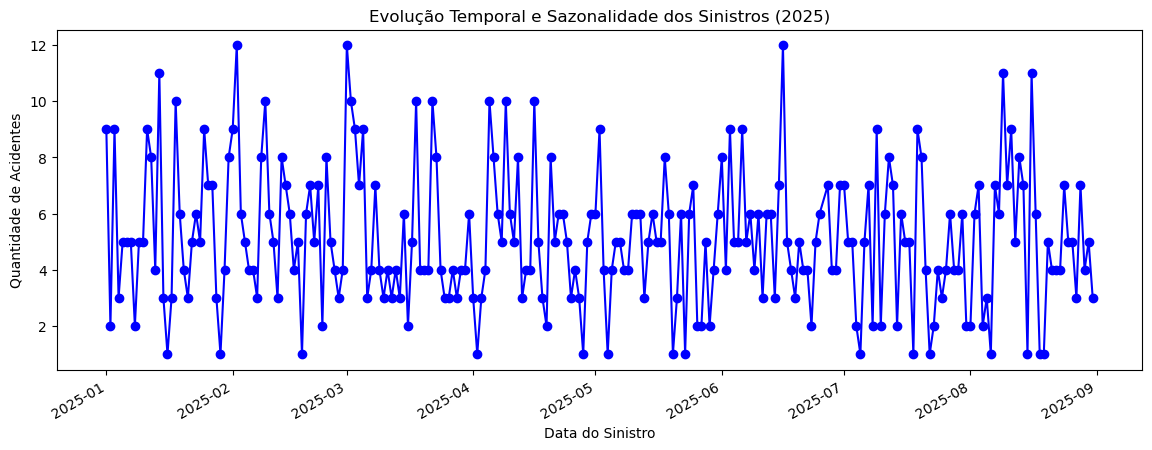

In [5]:
#Visualizando sazonalidade dos sinistros ao longo dos primeiros 9 meses (2025)
sazonalidade = df_filtrado['Data'].value_counts().sort_index()

plt.figure(figsize=(14, 5))
sazonalidade.plot(kind='line', color='blue', marker='o')
plt.title('Evolução Temporal e Sazonalidade dos Sinistros (2025)')
plt.xlabel('Data do Sinistro')
plt.ylabel('Quantidade de Acidentes')
plt.show()


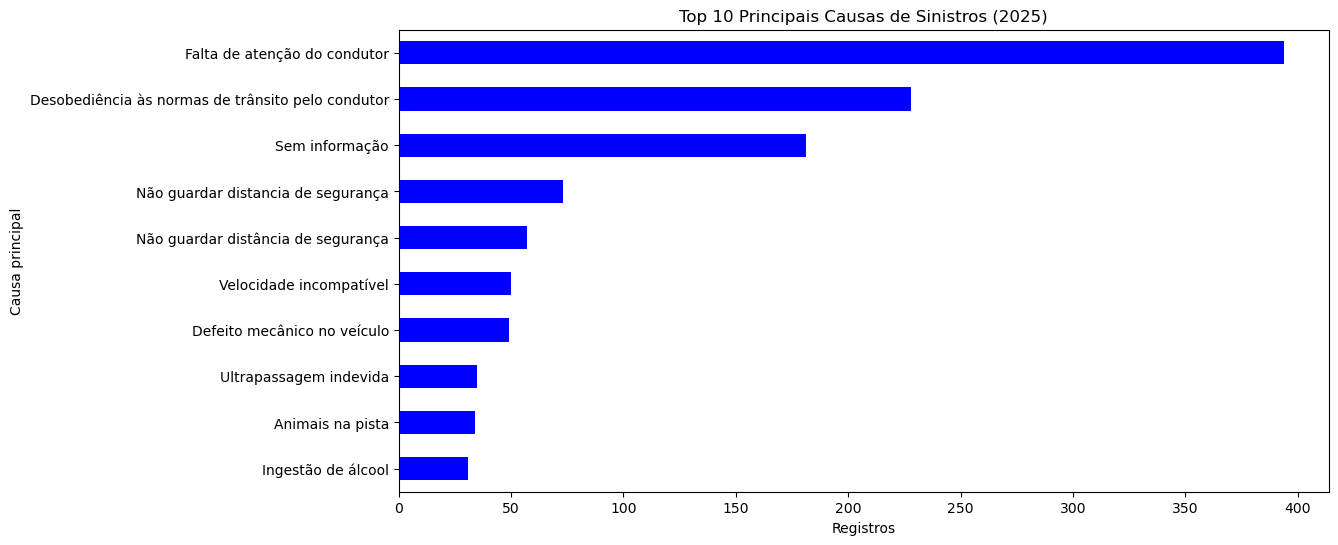

(None,
 Município            Causas Principais                                
 ARAPIRACA            Falta de atenção do condutor                         151
 MACEIO               Falta de atenção do condutor                          66
 MARECHAL DEODORO     Falta de atenção do condutor                          37
 PENEDO               Falta de atenção do condutor                          16
 MARAGOGI             Falta de atenção do condutor                          14
 RIO LARGO            Falta de atenção do condutor                          10
 CORURIPE             Sem informação                                        10
 UNIAO DOS PALMARES   Sem informação                                         9
 SAO SEBASTIAO        Sem informação                                         8
 LAGOA DA CANOA       Falta de atenção do condutor                           7
 SAO JOSE DA TAPERA   Sem informação                                         5
 CRAIBAS              Falta de atenção do condutor  

In [6]:
#Identificando a maior causa principal por Município
contagem = df_filtrado.groupby('Município')['Causas Principais'].value_counts()
top_causa_por_municipio = contagem.groupby(level=0).head(1).sort_values(ascending=False)
top_causa_por_municipio.head(20)

#Visualizando "Top Causas" gerais
top_causas = df_filtrado['Causas Principais'].value_counts().head(10)
plt.figure(figsize=(12, 6))
top_causas.sort_values(ascending=True).plot(kind='barh', color='blue')
plt.title('Top 10 Principais Causas de Sinistros (2025)')
plt.xlabel('Registros')
plt.ylabel('Causa principal')


plt.show(), top_causa_por_municipio.head(20)

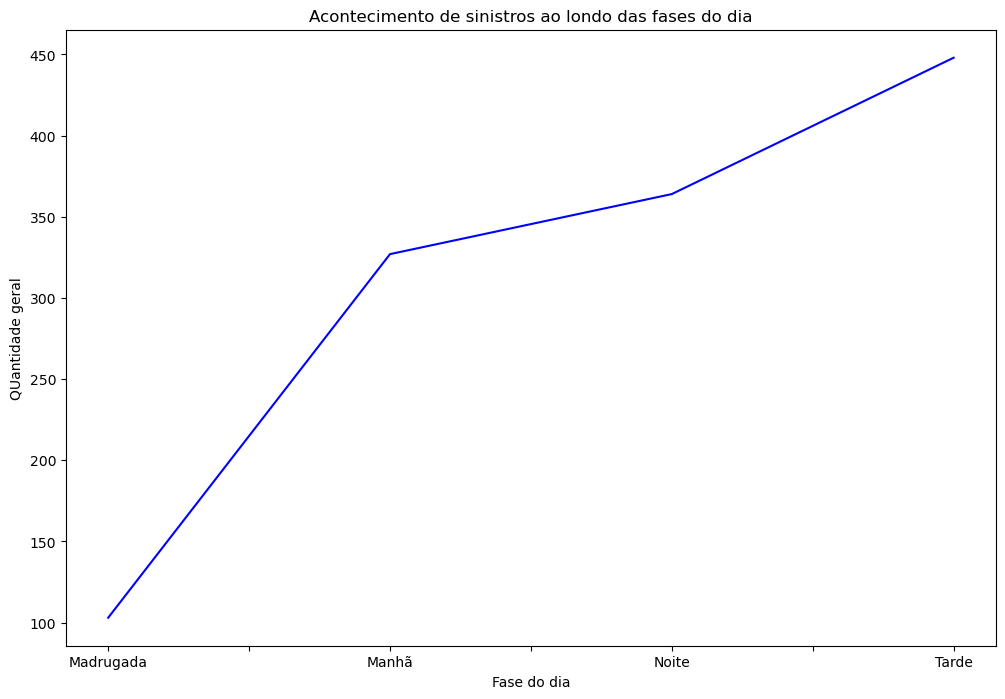

A média de acontecimentos de sinistros é as: 14:11:32


(None,
 None,
 Fase do Dia
 Tarde        448
 Noite        364
 Manhã        327
 Madrugada    103
 Name: count, dtype: int64)

In [7]:
#Identificando fatores relacionado ao horário
qtd_fase_dia = df_filtrado['Fase do Dia'].value_counts()
media_horario = df_filtrado['Hora'].mean()
media_formatada = str(media_horario).split()[-1].split('.')[0]

#Visualizando "Sinistros nas fases do dia"
plt.figure(figsize=(12, 8))
qtd_fase_dia.sort_values(ascending=True).plot(kind='line', color='blue')
plt.xlabel('Fase do dia')
plt.ylabel('QUantidade geral')
plt.title('Acontecimento de sinistros ao londo das fases do dia')
plt.show(), print(f"A média de acontecimentos de sinistros é as: {media_formatada}"), qtd_fase_dia

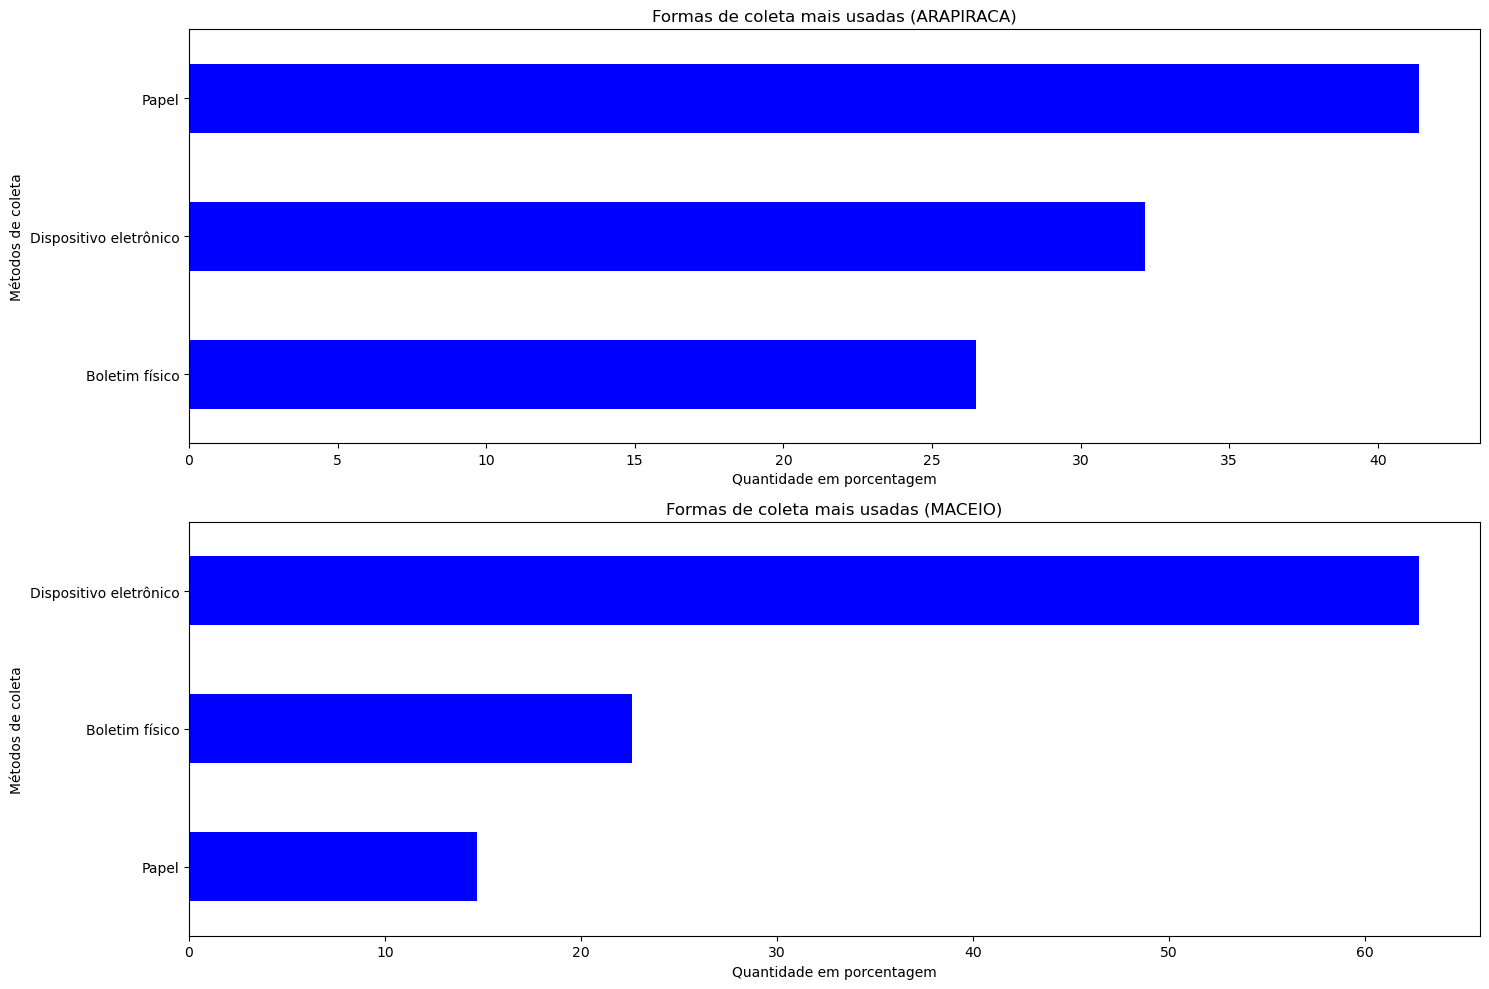

In [8]:
#Identificando o tipo de coleta mais usado em ARAPIRACA e MACEIO

registros_arapiraca = len(df_filtrado[df_filtrado['Município'] == 'ARAPIRACA'])
registros_maceio = len(df_filtrado[df_filtrado['Município'] == 'MACEIO'])

fontes_arapiraca = df_filtrado[df_filtrado['Município'] == 'ARAPIRACA']['Coleta'].value_counts()
fontes_maceio = df_filtrado[df_filtrado['Município'] == 'MACEIO']['Coleta'].value_counts()


porcentagem_tipo_coleta_arapiraca = ((fontes_arapiraca/registros_arapiraca) * 100)
porcentagem_tipo_coleta_maceio = ((fontes_maceio/registros_maceio) * 100)


#Visualizando porcentagem de uso das diferentes coletas (ARAPIRACA E MACEIO)
fig, ax = plt.subplots(2, figsize=(15, 10))

porcentagem_tipo_coleta_arapiraca.sort_values(ascending=True).plot(kind='barh', color='blue', ax=ax[0])
ax[0].set_title('Formas de coleta mais usadas (ARAPIRACA)')
ax[0].set_xlabel('Quantidade em porcentagem')
ax[0].set_ylabel('Métodos de coleta')

porcentagem_tipo_coleta_maceio.sort_values(ascending=True).plot(kind="barh", color='blue', ax=ax[1])
ax[1].set_title('Formas de coleta mais usadas (MACEIO)')
ax[1].set_xlabel('Quantidade em porcentagem')
ax[1].set_ylabel('Métodos de coleta')

plt.tight_layout()
plt.show()

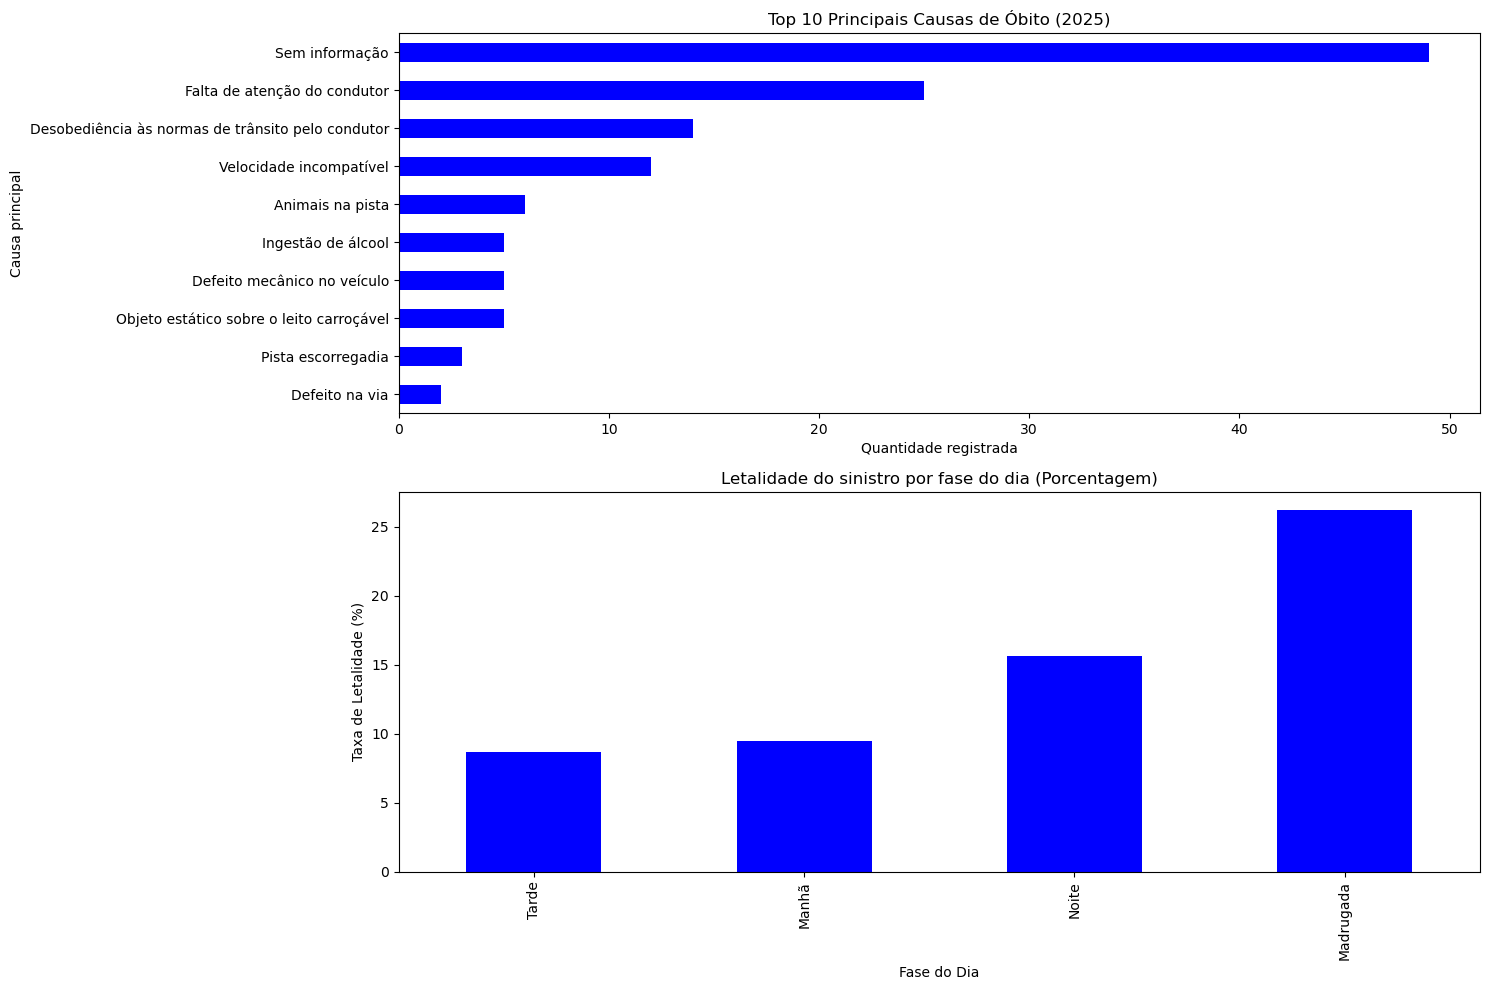

Número de óbitos registrados: 154.0


(None, None)

In [9]:
#Explorando óbitos em sinistros
total_vitimas = df_filtrado['Óbito'].sum()
principais_causas_obito = df_filtrado[df_filtrado['Óbito'].notnull()]['Causas Principais'].value_counts().head(10)

#Verificando letalidade em fases do dia
obitos_per_fasedia = df_filtrado.groupby("Fase do Dia")['Óbito'].sum()
letalidade = ((obitos_per_fasedia/qtd_fase_dia) * 100)


#Visualizando "Óbitos e suas causas" e "Letalidade nas fases do dia"
fig, ax = plt.subplots(2, figsize=(15, 10))

principais_causas_obito.sort_values(ascending=True).plot(kind='barh', color='blue', ax=ax[0])
ax[0].set_title('Top 10 Principais Causas de Óbito (2025)')
ax[0].set_xlabel('Quantidade registrada')
ax[0].set_ylabel('Causa principal')

letalidade.sort_values(ascending=True).plot(kind="bar", color='blue', ax=ax[1])
ax[1].set_title('Letalidade do sinistro por fase do dia (Porcentagem)')
ax[1].set_xlabel('Fase do Dia')
ax[1].set_ylabel('Taxa de Letalidade (%)')

plt.tight_layout()
plt.show(), print(f"Número de óbitos registrados: {total_vitimas}")